In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_file(path, sepa):
    """
    recupère le fichier csv donnée avec le séparateur ';' et retourne un dataFrame.

    Args:
        path (str): Le chemin vers le fichier CSV.

    Returns:
        pd.DataFrame: Les données chargées.
    """

    # ouvir le fichier en dataframe
    df = pd.read_csv(path, sep=sepa)
    return df

In [3]:
def numerise_col(df, col):
    """
    recupere une colonne d'un dataframe et passe tout ses valeurs en float

    Args:
        df(pd.DataFrame): le dataframe à nettoyer
        col(str): le nom de la colonne
    """

    # passer la variable en srting pour pouvoir les manipuler
    df[col] = df[col].astype(str)

    # on transforme les , en .
    df[col] = df[col].str.replace(",", ".", regex=False)

    # on supprime tous ce qui n'est pas des chiffres de 0 a 9 et .
    df[col] = df[col].str.replace(r"[^0-9.]", "", regex=True)

    # conversion en float
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # NA remplacé les vides par 0
    df[col] = df[col].fillna(df[col].mean())

    # arrondir 2 chiffres
    df[col] = df[col].round(2)

In [4]:
def string_col(df, col):
    """
    Reformatte bien la collone donnée de la dataframe en string
    """
    #change la colonne en stt pour pouvoir mieux les manipuler et retire les espaces avant et apres le str
    df[col] = df[col].astype(str).str.strip()

    # reformate les NAN possiblement ecrit de manière differentes
    df[col] = df[col].replace({"nan": np.nan, "none": np.nan, "n/a": np.nan, "": np.nan})
    df[col] = df[col].astype("string")

In [5]:
def date_formating(df):
    df["Date"] = df["Date"].astype(str).str.strip()

    df["Date"] = df["Date"].astype(str).str.replace(r"[/ ]", "-", regex=True)
    df["Date"] = df["Date"].str.rstrip("-")
    df["Date"] = df["Date"].str.replace(r"^(\d{2})-(\d{4})$", r"\2-\1", regex=True)
    # changer le format de la date pour qu'elle soit plus manipulable et met NaN si la date est pas bonne
    
    df.loc[:, "Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Annee"] = df["Date_dt"].dt.year
    df["Mois"] = df["Date_dt"].dt.month


In [6]:
def clean_data(df_input):
    """
    nettoie le dataframe en supprimant les doublons et les lignes avec des
    informations manquantes des principales information.

    Args:
        df_input (pd.DataFrame): le dataframe à nettoyer.
    """
    # crée une copie du df pour pas le modifier 
    df = df_input.copy()

    

    # colonnes de texte
    cols_non_numerique = [
        "Date",
        "Date_dt",
        "Service",
        "Gare de départ",
        "Gare d'arrivée",
        "Commentaire annulations",
        "Commentaire retards au départ",
        "Commentaire retards à l'arrivée",
    ]
    # definir les collones inutiles
    useless_col = [
        "Commentaire annulations",
        "Commentaire retards au départ",
        "Commentaire retards à l'arrivée",
    ]

    date_formating(df)

    df = df.drop(columns=useless_col)
    
    # boucle pour clean les colonnes numerique et collones de texte
    for col in df.columns:
        if col not in cols_non_numerique:
            numerise_col(df, col)
        else:
            string_col(df,col)

    # supprime toutes les donnée ou Date, Gare de depart ou Gare d'arrivée ne sont pas rempli
    df = df.dropna(subset=["Date_dt","Gare de départ","Gare d'arrivée","Service"])

    # supprime toutes les donnée dupliquées"
    df = df.drop_duplicates()

    #supprime les donnée ou date Gare de depart et Gare d'arrivée soont identique0
    df = df.drop_duplicates(subset=["Date", "Gare de départ", "Gare d'arrivée"])
    # revoie les données nettoyée de la dataframe
    return df

In [7]:
def save_df(df):
    """
    crée un fichier cleaned_dataset.csv ou stocker le dataframe en csv

    Args:
        df (pd.DataFrame): le dataframe à stocker
    """
    df.to_csv("cleaned_dataset.csv", index=False)

## Adding graphs

In [8]:


    
def aff_graph(valX, valY=None, labelX=None, labelY=None, title=None, graph_type="line"):

    plt.figure(figsize=(12, 6))

    if graph_type == "line":
        plt.plot(valX, valY, linewidth=2)

    elif graph_type == "bar":
        plt.bar(valX, valY)

    elif graph_type == "scatter":
        plt.scatter(valX, valY)

    elif graph_type == "hist":
        plt.hist(valX, bins=30)

    else:
        raise ValueError("Type inconnu")

    if labelX:
        plt.xlabel(labelX)

    if labelY:
        plt.ylabel(labelY)

    if title:
        plt.title(title)

    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.show()

## Main

In [9]:
df_dirty = get_file("dataset.csv",";")
df = clean_data(df_dirty)
save_df(df)

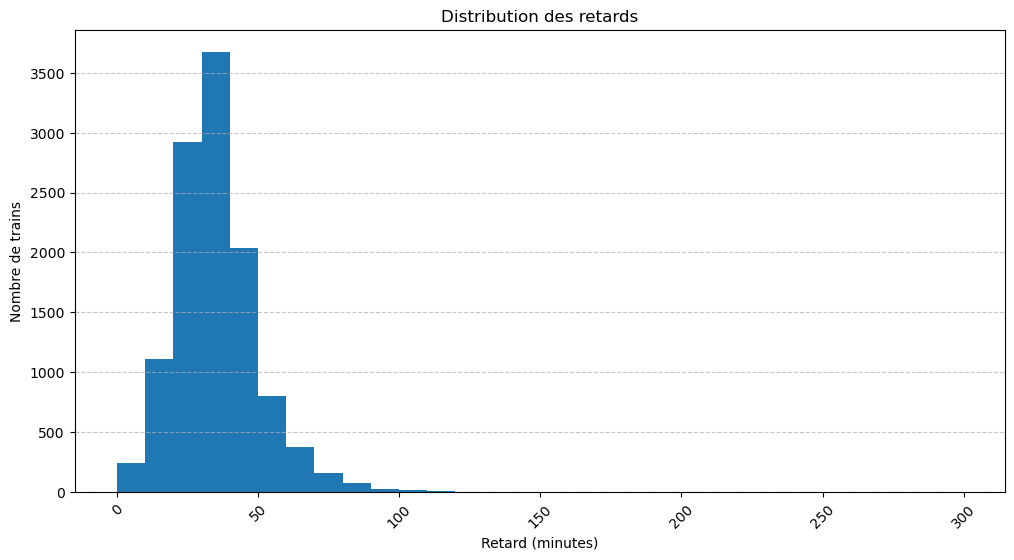

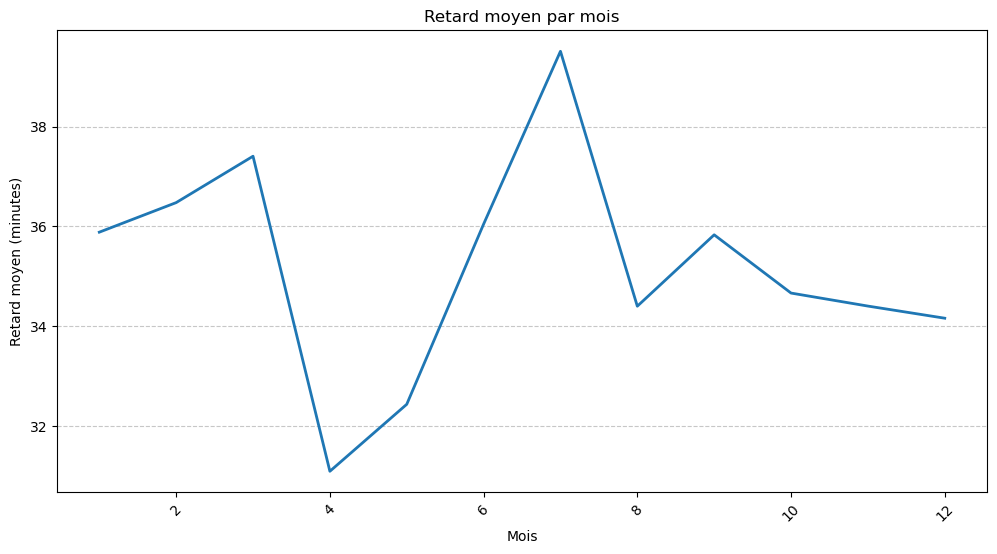

In [10]:

delay_col = "Retard moyen des trains en retard à l'arrivée"

delays = pd.to_numeric(df[delay_col], errors="coerce").dropna()

aff_graph(
    delays,
    labelX="Retard (minutes)",
    labelY="Nombre de trains",
    title="Distribution des retards",
    graph_type="hist",
)

# Make sure month exists
df["month"] = pd.to_datetime(df["Date"]).dt.month

grouped_month = df.groupby("month")[delay_col].mean()

aff_graph(
    grouped_month.index,
    grouped_month.values,
    labelX="Mois",
    labelY="Retard moyen (minutes)",
    title="Retard moyen par mois",
    graph_type="line",
)
